# Fake News Detection System
<ol start="0">
<li> Data Collection </li>
<li> Data Visualization</li>
<li> Data Cleaning  </li>
</ol>

### Data Collection

In [235]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
import string
import unicodedata
import seaborn as sns


In [236]:
df_test = pd.read_csv("C:\\Users\\bench\\Downloads\\liar_dataset\\test.tsv", sep='\t',header=None)
df_train = pd.read_csv("C:\\Users\\bench\\Downloads\\liar_dataset\\train.tsv", sep='\t',header=None)
df_validation = pd.read_csv("C:\\Users\\bench\\Downloads\\liar_dataset\\valid.tsv", sep='\t',header=None)

In [237]:
dataset_description = "A BENCHMARK DATASET FOR FAKE NEWS DETECTION"
dataset_source = "LIAR dataset from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"

In [238]:
columns = pd.Series([
    'Id',
    'Label',
    'Statement',
    'Subject',
    'Speaker',
    'Speaker Job Title',
    'State Info',
    'Party Affiliation',
    'Barely True Counts',
    'False Counts',
    'Half True Counts',
    'Mostly True Counts',
    'Pants on Fire Counts',
    'Context',

])

In [239]:
df_test.columns = columns
df_train.columns = columns
df_validation.columns = columns


In [240]:
def describe_dataset(df, name):
    print("The dataset is divided into three parts: training, validation, and test sets.")
    print(f"Dataset source {dataset_source}")
    print(f"{name} set:")
    print(f"Number of samples: {len(df)}")

In [241]:
def format(df,name): 
    print(f"\n{name} set:")
    print(df.head())
    print(f'df.shape: {df.shape}')
    print("\nStatistical summary:")
    print(df.describe(include='all'))

In [242]:
def understand_data(df,name):
    print(f"\n{name} set:")
    print("Columns and their data types:")
    print(columns)
    print(df.isnull().sum())


In [243]:
describe_dataset(df_train,"Training")

The dataset is divided into three parts: training, validation, and test sets.
Dataset source LIAR dataset from https://www.cs.ucsb.edu/~william/data/liar_dataset.zip
Training set:
Number of samples: 10240


In [244]:
format(df_train,"Training")


Training set:
           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info Party Affi

In [245]:
understand_data(df_train,"Training")


Training set:
Columns and their data types:
0                       Id
1                    Label
2                Statement
3                  Subject
4                  Speaker
5        Speaker Job Title
6               State Info
7        Party Affiliation
8       Barely True Counts
9             False Counts
10        Half True Counts
11      Mostly True Counts
12    Pants on Fire Counts
13                 Context
dtype: object
Id                         0
Label                      0
Statement                  0
Subject                    2
Speaker                    2
Speaker Job Title       2898
State Info              2210
Party Affiliation          2
Barely True Counts         2
False Counts               2
Half True Counts           2
Mostly True Counts         2
Pants on Fire Counts       2
Context                  102
dtype: int64


In [246]:
def merge_datasets(df1, df2, df3):
    merged_df = pd.concat([df1, df2, df3], ignore_index=True)
    return merged_df

merged_df = merge_datasets(df_train, df_validation, df_test)


In [247]:
print("Merged Dataset:")
print(merged_df.shape)


Merged Dataset:
(12791, 14)


In [248]:
def overview_merged_dataset(merged_df):
    print("Merged Dataset Overview:")
    print(merged_df.head())
    print(f"Merged dataset shape: {merged_df.shape}") #(12791, 14)
    print("Infos about the columns : ")
    print(merged_df.info())

In [249]:
overview_merged_dataset(merged_df)

Merged Dataset Overview:
           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info 

In [250]:
#calculating null values in each column
def null_values_summary(merged_df):
    print("\nNull values in each column:")
    print(merged_df.isnull().sum())

In [251]:
null_values_summary(merged_df)


Null values in each column:
Id                         0
Label                      0
Statement                  0
Subject                    2
Speaker                    2
Speaker Job Title       3568
State Info              2751
Party Affiliation          2
Barely True Counts         2
False Counts               2
Half True Counts           2
Mostly True Counts         2
Pants on Fire Counts       2
Context                  131
dtype: int64


In [252]:
def understand_columns_values(merged_df,column_name):
    print(f"\nUnique values for the column {column_name}:")
    print(merged_df[column_name].value_counts())

#loop through all cols
# for col in merged_df.columns:
#     understand_columns_values(merged_df, col)

In [253]:
for col in merged_df.columns:
     understand_columns_values(merged_df, col)


Unique values for the column Id:
Id
2635.json     1
1680.json     1
8964.json     1
11484.json    1
2666.json     1
             ..
6934.json     1
2595.json     1
1710.json     1
1351.json     1
6743.json     1
Name: count, Length: 12791, dtype: int64

Unique values for the column Label:
Label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

Unique values for the column Statement:
Statement
On a cap-and-trade plan.                                                                                                                                             3
On changing the rules for filibusters on presidential nominees                                                                                                       3
Martin Luther King Jr. was a Republican.                                                                                                                             2
Some 

In [254]:
def identify_null_values(df,col_name):
    filt = df[col_name].isnull() == True
    print(f"\nRows with null values in column {col_name}:")
    print(df.loc[filt,['Id',col_name]])


In [255]:
for col in merged_df.columns:
     identify_null_values(merged_df, col)


Rows with null values in column Id:
Empty DataFrame
Columns: [Id, Id]
Index: []

Rows with null values in column Label:
Empty DataFrame
Columns: [Id, Label]
Index: []

Rows with null values in column Statement:
Empty DataFrame
Columns: [Id, Statement]
Index: []

Rows with null values in column Subject:
             Id Subject
2142   638.json     NaN
9375  1626.json     NaN

Rows with null values in column Speaker:
             Id Speaker
2142   638.json     NaN
9375  1626.json     NaN

Rows with null values in column Speaker Job Title:
              Id Speaker Job Title
3      1123.json               NaN
4      9028.json               NaN
6      2342.json               NaN
8      5602.json               NaN
13     8616.json               NaN
...          ...               ...
12777  9241.json               NaN
12781  1005.json               NaN
12784  5671.json               NaN
12785  6699.json               NaN
12790  6743.json               NaN

[3568 rows x 2 columns]

Rows with n

In [256]:
#identify float columns 

def float_columns_summary(merged_df):
    float_cols = merged_df.select_dtypes(include=['float64']).columns
    print("\nFloat columns summary:")
    for col in float_cols:
        print(f"{col}:")
        print(merged_df[col].describe())
        print("Missing values :")
        identify_null_values(merged_df, col)
# for col in merged_df.select_dtypes(include=['float64']).columns:
#     identify_null_values(merged_df, col)

# float_columns_summary(merged_df)
# null_values_summary(merged_df)

In [257]:
for col in merged_df.select_dtypes(include=['float64']).columns:
     identify_null_values(merged_df, col)


Rows with null values in column Barely True Counts:
             Id  Barely True Counts
2142   638.json                 NaN
9375  1626.json                 NaN

Rows with null values in column False Counts:
             Id  False Counts
2142   638.json           NaN
9375  1626.json           NaN

Rows with null values in column Half True Counts:
             Id  Half True Counts
2142   638.json               NaN
9375  1626.json               NaN

Rows with null values in column Mostly True Counts:
             Id  Mostly True Counts
2142   638.json                 NaN
9375  1626.json                 NaN

Rows with null values in column Pants on Fire Counts:
             Id  Pants on Fire Counts
2142   638.json                   NaN
9375  1626.json                   NaN


In [258]:
float_columns_summary(merged_df)


Float columns summary:
Barely True Counts:
count    12789.000000
mean        11.583939
std         18.978037
min          0.000000
25%          0.000000
50%          2.000000
75%         12.000000
max         70.000000
Name: Barely True Counts, dtype: float64
Missing values :

Rows with null values in column Barely True Counts:
             Id  Barely True Counts
2142   638.json                 NaN
9375  1626.json                 NaN
False Counts:
count    12789.000000
mean        13.359059
std         24.140086
min          0.000000
25%          0.000000
50%          2.000000
75%         15.000000
max        114.000000
Name: False Counts, dtype: float64
Missing values :

Rows with null values in column False Counts:
             Id  False Counts
2142   638.json           NaN
9375  1626.json           NaN
Half True Counts:
count    12789.000000
mean        17.185785
std         35.847678
min          0.000000
25%          0.000000
50%          3.000000
75%         13.000000
max       

In [259]:
def check_duplicates(df,col_name):
    duplicates = df[col_name].duplicated().any()
    print(f"\nDuplicate counts based on column {col_name}:")
    print(duplicates)

# for col in merged_df.columns:
#     check_duplicates(merged_df, col)

#find duplicate rows based on all columns except 'Id'
# print(merged_df.drop(columns=['Id']).duplicated().sum()) #=> 1
# filt_dup_rows = merged_df.drop(columns=['Id']).duplicated(keep=False) #keep = false to not just show one instance of duplicates
# print(merged_df[filt_dup_rows])

In [260]:
for col in merged_df.columns:
     check_duplicates(merged_df, col)


Duplicate counts based on column Id:
False

Duplicate counts based on column Label:
True

Duplicate counts based on column Statement:
True

Duplicate counts based on column Subject:
True

Duplicate counts based on column Speaker:
True

Duplicate counts based on column Speaker Job Title:
True

Duplicate counts based on column State Info:
True

Duplicate counts based on column Party Affiliation:
True

Duplicate counts based on column Barely True Counts:
True

Duplicate counts based on column False Counts:
True

Duplicate counts based on column Half True Counts:
True

Duplicate counts based on column Mostly True Counts:
True

Duplicate counts based on column Pants on Fire Counts:
True

Duplicate counts based on column Context:
True


In [261]:
float_cols = merged_df.select_dtypes(include=['float64']).columns


### Data Visualization


In [263]:
def plott(df,col) :
    
        plt.figure(figsize=(8, 6))
        plt.hist(df[col].dropna(), bins=30, color='blue', alpha=0.7)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.75)
        plt.show()

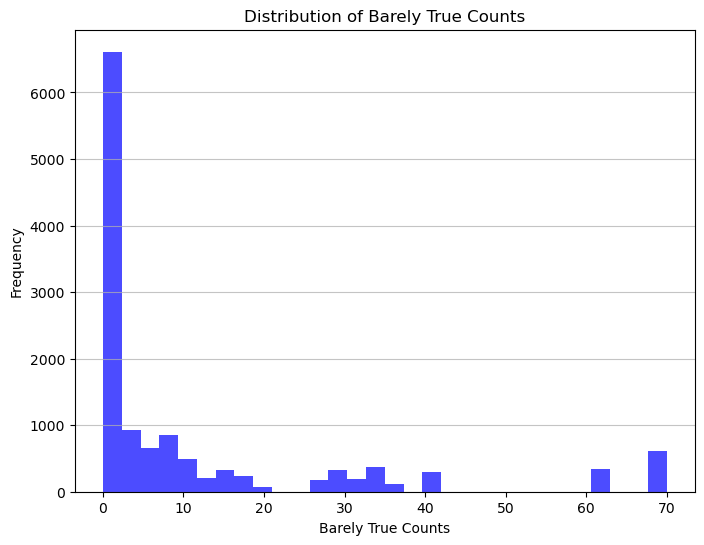

In [264]:
plott(merged_df,'Barely True Counts')

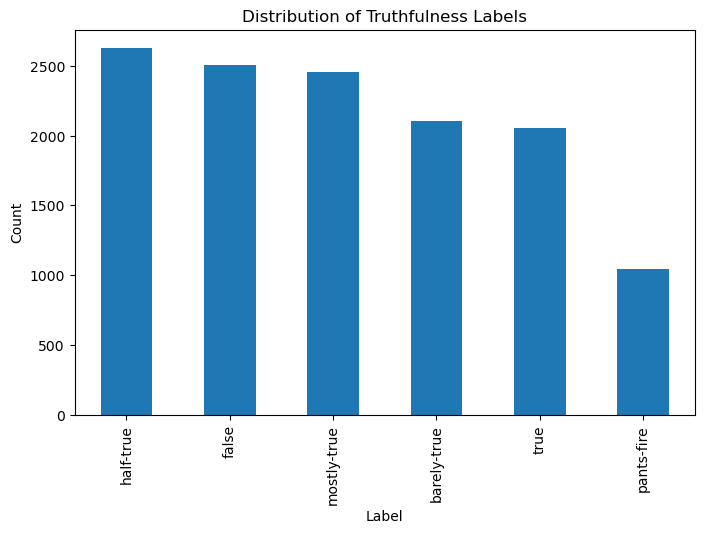

In [265]:
plt.figure(figsize=(8,5))
merged_df["Label"].value_counts().plot(kind="bar")
plt.title("Distribution of Truthfulness Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

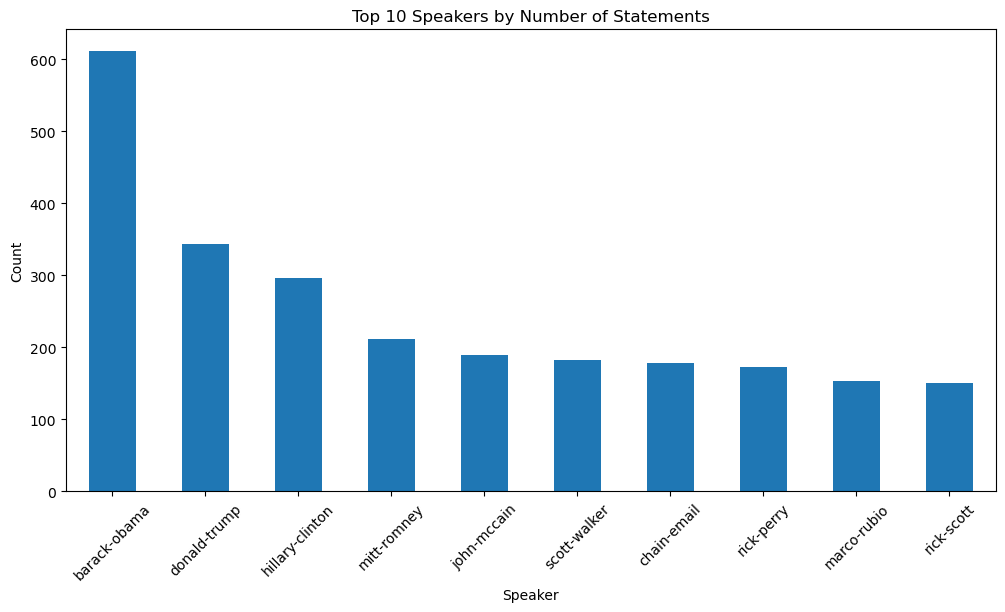

In [266]:
plt.figure(figsize=(12, 6))
merged_df['Speaker'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Speakers by Number of Statements')
plt.xlabel('Speaker')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

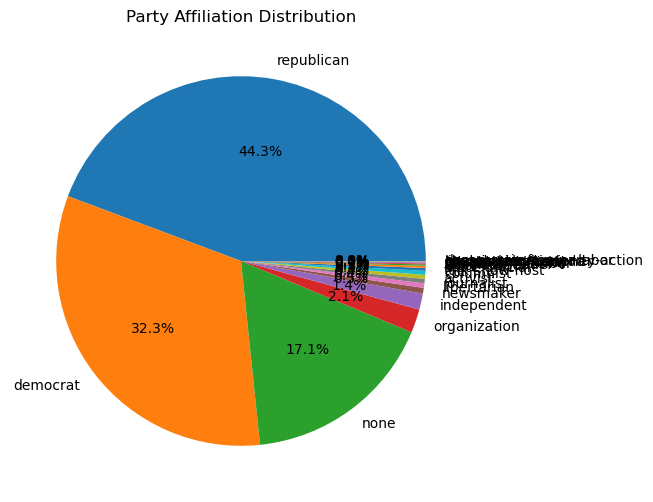

In [267]:
plt.figure(figsize=(8, 6))
merged_df['Party Affiliation'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Party Affiliation Distribution')
plt.ylabel('')
plt.show()

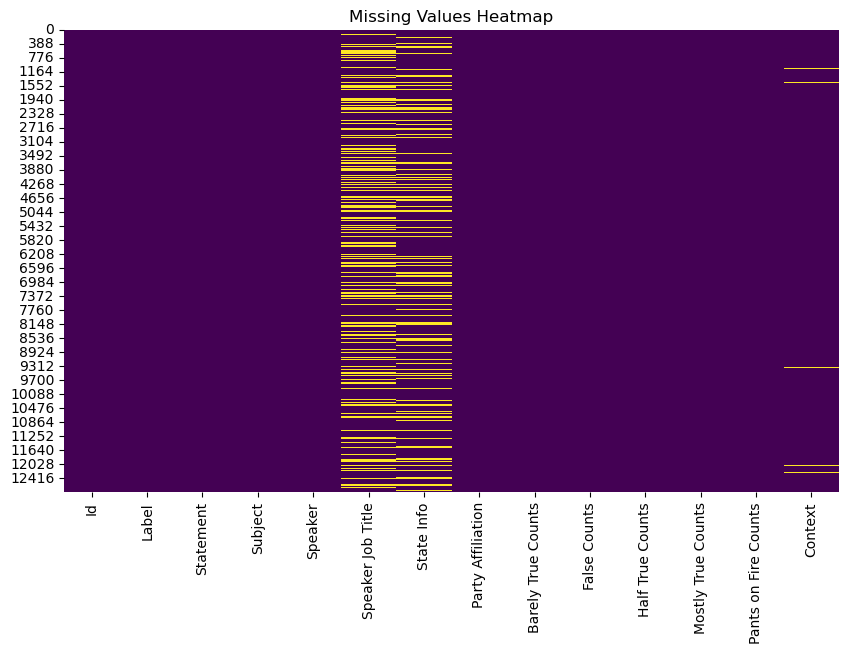

In [268]:
plt.figure(figsize=(10, 6))
sns.heatmap(merged_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### Data Cleaning

In [270]:
merged_df.dtypes

Id                       object
Label                    object
Statement                object
Subject                  object
Speaker                  object
Speaker Job Title        object
State Info               object
Party Affiliation        object
Barely True Counts      float64
False Counts            float64
Half True Counts        float64
Mostly True Counts      float64
Pants on Fire Counts    float64
Context                  object
dtype: object

In [271]:
# Convert count columns to integer
count_columns = [
    'Barely True Counts',
    'False Counts',
    'Half True Counts',
    'Mostly True Counts',
    'Pants on Fire Counts'
]

merged_df[count_columns] = merged_df[count_columns].astype('Int64')  # nullable int type

In [272]:
merged_df.dtypes

Id                      object
Label                   object
Statement               object
Subject                 object
Speaker                 object
Speaker Job Title       object
State Info              object
Party Affiliation       object
Barely True Counts       Int64
False Counts             Int64
Half True Counts         Int64
Mostly True Counts       Int64
Pants on Fire Counts     Int64
Context                 object
dtype: object

In [273]:
def clean_text(text):
   # Function to clean and lemmatize text data
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters and punctuation
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8') # Normalize accented characters (e.g., é -> e)
    text = re.sub(r'\s+', ' ', text).strip()  # Remove unnecessary whitespace
    
    return text

In [274]:
# Apply text cleaning
merged_df['statement_cleaned'] = merged_df['Statement'].apply(clean_text)

# Display the resulting DataFrame
print(merged_df.head())

           Id        Label                                          Statement  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                              Subject         Speaker     Speaker Job Title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

  State Info Party Affiliation  Barely

In [275]:
# Map labels to normalized categories
label_mapping = {
    'barely-true': 'barely true',
    'false': 'false',
    'half-true': 'half true',
    'mostly-true': 'mostly true',
    'pants-fire': 'pants on fire',
    'true': 'true'
}

merged_df['Label'] = merged_df['Label'].str.lower().map(label_mapping)

In [276]:
# Check if any labels are invalid after mapping
invalid_labels = merged_df['Label'].isnull().sum()
print(f"Invalid labels after mapping: {invalid_labels}")

Invalid labels after mapping: 0


In [277]:
print("Before:", merged_df.shape)
merged_df = merged_df.dropna(subset=['Subject'])
print("After:", merged_df.shape)


Before: (12791, 15)
After: (12789, 15)


In [278]:
null_values_summary(merged_df)


Null values in each column:
Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title       3566
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                  129
statement_cleaned          0
dtype: int64


In [279]:
merged_df['Context'].value_counts().head(10)

Context
a news release       309
an interview         286
a press release      282
a speech             259
a TV ad              222
a tweet              190
a campaign ad        164
a television ad      161
a radio interview    126
a debate             114
Name: count, dtype: int64

In [280]:
#show context missing values
filt_context = merged_df['Context'].isna() == True
merged_df.loc[filt_context]
#SINCE context column isn't essential as the other columns and it has 1% of missing values only 
#we can just replace them with  '<MISSING>'(better than unknown when it comes to modeling)
merged_df.loc[filt_context, 'Context'] = '<MISSING>'

In [281]:
merged_df.isna().sum()

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title       3566
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
dtype: int64

In [282]:
merged_df['Speaker Job Title'].value_counts()

Speaker Job Title
President                                           615
U.S. Senator                                        595
Governor                                            487
President-Elect                                     343
U.S. senator                                        328
                                                   ... 
Pro-gambling group                                    1
Government agency                                     1
chancellor and president, Liberty University          1
Spokeswoman for the Narragansett Bay commission       1
senior fellow, Foreign Policy Research Institute      1
Name: count, Length: 1354, dtype: int64

In [283]:
#func to normalize speaker job title 
def normalize_title(t):
    t = t.lower()
    if t == "<missing>":
        return "missing"

    # politics / government
    if "president" in t: return "executive_president"
    if "senator" in t: return "legislator_senator"
    if "representative" in t or "congress" in t: return "legislator_house"
    if "governor" in t: return "executive_governor"
    if "mayor" in t: return "executive_mayor"
    if "secretary" in t or "minister" in t: return "government_official"

    # media / comms
    if "journalist" in t or "reporter" in t or "anchor" in t or "host" in t:
        return "media"

    # legal
    if "attorney" in t or "lawyer" in t or "judge" in t:
        return "legal"

    # academic
    if "professor" in t or "research" in t or "university" in t:
        return "academic"

    # business
    if "ceo" in t or "founder" in t or "executive" in t or "business" in t:
        return "business"

    # activists / orgs
    if "director" in t or "chair" in t or "president of" in t:
        return "organization_leader"

    return "other"



In [284]:
#Got Problems when normalizing cuz of float values 
#shows float values in Speaker Job Title
mask_float = merged_df["Speaker Job Title"].apply(lambda x: isinstance(x, float))
merged_df.loc[mask_float, "Speaker Job Title"]

3        NaN
4        NaN
6        NaN
8        NaN
13       NaN
        ... 
12777    NaN
12781    NaN
12784    NaN
12785    NaN
12790    NaN
Name: Speaker Job Title, Length: 3566, dtype: object

In [285]:
#Replacing nan with '<MISSING>'
merged_df.fillna({'Speaker Job Title':'<MISSING>'},inplace = True)


In [286]:
merged_df.isna().sum() #0 na speaker job title

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title          0
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
dtype: int64

In [287]:
merged_df['Speaker Job Category'] = merged_df['Speaker Job Title'].apply(normalize_title) 

In [288]:
merged_df['Speaker Job Category'].value_counts()

Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

In [289]:
#now lets go deeply with 'Other' 
group_by_sjc = merged_df.groupby('Speaker Job Category')
other_grp = group_by_sjc.get_group('other')
other_grp[['Speaker Job Title','Speaker Job Category']].value_counts()

#found it still has many titles 

Speaker Job Title                        Speaker Job Category
Social media posting                     other                   100
Candidate for U.S. Senate and physician  other                    52
House Majority Leader                    other                    45
author                                   other                    44
consultant                               other                    36
                                                                ... 
Milwaukee County supervisor              other                     1
Milwaukee County Supervisor              other                     1
Artist                                   other                     1
Milwaukee Alderman                       other                     1
501 (c) (4) educational group            other                     1
Name: count, Length: 620, dtype: int64

In [290]:
#map the rest 
#2nd func to normalize
import re

def bucket_title(t):
    t = str(t).strip().lower()
    if t in ["<missing>", "nan", "none"]:
        return "missing"

    # politics / gov (broad)
    if any(k in t for k in [
        "president", "vice president", "president-elect",
        "senator", "u.s. senator", "us senator",
        "representative", "congress", "house majority leader",
        "majority leader", "minority leader", "speaker of the house",
        "governor", "mayor", "secretary", "minister", "commissioner",
        "state rep", "state representative", "state senator",
        "candidate", "campaign"
    ]):
        return "politics_government"

    # media / journalism
    if any(k in t for k in [
        "journalist", "reporter", "anchor", "host", "editor",
        "news", "columnist", "writer", "correspondent",
        "abc", "cnn", "fox", "msnbc"
    ]) or re.search(r"\b(author)\b", t):
        return "media"

    # academic / research / think tank
    if any(k in t for k in [
        "professor", "university", "research", "fellow",
        "council on foreign relations", "think tank", "institute"
    ]):
        return "academic_thinktank"

    # legal
    if any(k in t for k in ["attorney", "lawyer", "judge", "prosecutor"]):
        return "legal"

    # business / professional
    if any(k in t for k in [
        "ceo", "founder", "executive", "consultant",
        "accountant", "manager", "analyst", "entrepreneur"
    ]):
        return "business"

    # activism / NGO / org leader
    if any(k in t for k in [
        "activist", "advocate", "nonprofit", "ngo",
        "executive director", "director", "chair", "campaign chair"
    ]):
        return "activist_ngo"

    # healthcare (optional bucket)
    if any(k in t for k in ["physician", "doctor", "medical", "health"]):
        return "healthcare"

    return "other"


In [291]:
merged_df['Speaker Job Category'].value_counts()


Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

In [292]:
#Assuming all values are not null and not duplicated 
merged_df['Id'].value_counts() 
merged_df['Id'].isna().sum()

#updating id structure 
def update_id_structure (Id) :
    Id = Id.split('.')[0]
    return Id
merged_df['Id'] = merged_df['Id'].apply(update_id_structure) 
merged_df['Id']
merged_df['Id'].astype('int64') #assuming all id's now are integers

0         2635
1        10540
2          324
3         1123
4         9028
         ...  
12786     7334
12787     9788
12788    10710
12789     3186
12790     6743
Name: Id, Length: 12789, dtype: int64

In [293]:
merged_df.isna().sum()

Id                         0
Label                      0
Statement                  0
Subject                    0
Speaker                    0
Speaker Job Title          0
State Info              2749
Party Affiliation          0
Barely True Counts         0
False Counts               0
Half True Counts           0
Mostly True Counts         0
Pants on Fire Counts       0
Context                    0
statement_cleaned          0
Speaker Job Category       0
dtype: int64

In [294]:
merged_df['State Info'].value_counts()

State Info
Texas             1260
Florida           1231
Wisconsin          900
New York           829
Illinois           692
                  ... 
Virginia             1
United Kingdom       1
China                1
Rhode island         1
Georgia              1
Name: count, Length: 84, dtype: int64

In [295]:
filt_na_state_info = merged_df['State Info'].isna() == True
merged_df.loc[filt_na_state_info]

,Id,Label,Statement,Subject,Speaker,Speaker Job Title,State Info,Party Affiliation,Barely True Counts,False Counts,Half True Counts,Mostly True Counts,Pants on Fire Counts,Context,statement_cleaned,Speaker Job Category
3,1123,false,Health care reform legislation is likely to ma...,health-care,blog-posting,<MISSING>,NaN,none,7,19,3,5,44,a news release,health care reform legislation is likely to ma...,missing
8,5602,half true,"However, it took $19.5 million in Oregon Lotte...",jobs,oregon-lottery,<MISSING>,NaN,organization,0,0,1,0,1,a website,however it took 195 million in oregon lottery ...,missing
13,8616,mostly true,The economy bled $24 billion due to the govern...,"economy,federal-budget,health-care",doonesbury,<MISSING>,NaN,none,0,0,2,4,0,a Doonesbury strip in the Sunday comics,the economy bled 24 billion due to the governm...,missing
17,3863,barely true,"U.S. Rep. Ron Kind, D-Wis., and his fellow Dem...",federal-budget,national-republican-congressional-committee,<MISSING>,NaN,republican,18,9,8,5,8,a news release,us rep ron kind dwis and his fellow democrats ...,missing
21,9867,mostly true,The United States has the highest corporate ta...,"corporations,taxes",eric-bolling,"Co-host on Fox News Channel's ""The Five""",NaN,none,2,1,1,1,0,"a discussion on Fox News' ""The Five""",the united states has the highest corporate ta...,media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12758,6045,pants on fire,Says Hawaii Gov. Neil Abercrombie made a late-...,obama-birth-certificate,chain-email,<MISSING>,NaN,none,11,43,8,5,105,e-mail messages circulating on the Internet,says hawaii gov neil abercrombie made a lateni...,missing
12777,9241,true,I am the only senator who turned down the stat...,pensions,don-balfour,<MISSING>,NaN,republican,0,0,0,2,0,campaign flier,i am the only senator who turned down the stat...,missing
12781,1005,pants on fire,Obama used $20 million in federal money to emm...,foreign-policy,chain-email,<MISSING>,NaN,none,11,43,8,5,105,a chain e-mail,obama used 20 million in federal money to emmi...,missing
12785,6699,pants on fire,Sen. Bob Menendez voted to enact a new tax on ...,"health-care,housing,income,taxes",menendez-facts,<MISSING>,NaN,none,0,0,0,0,1,a blog,sen bob menendez voted to enact a new tax on t...,missing


In [296]:
#Since State info isnt considered as an important feature for our case then we'll replace NaN values with Unkown .
merged_df.fillna({'State Info':'Unknown'},inplace = True)

In [297]:
merged_df.isna().sum()

Id                      0
Label                   0
Statement               0
Subject                 0
Speaker                 0
Speaker Job Title       0
State Info              0
Party Affiliation       0
Barely True Counts      0
False Counts            0
Half True Counts        0
Mostly True Counts      0
Pants on Fire Counts    0
Context                 0
statement_cleaned       0
Speaker Job Category    0
dtype: int64

In [298]:
#normalazing state info 
merged_df['State Info'] = (
    merged_df['State Info']
    .astype(str)
    .str.normalize('NFKC')
    .str.replace('\xa0', ' ', regex=False)
    .str.strip()
    .str.lower()
)


In [299]:
# pd.set_option('display.max_rows', None)
merged_df['State Info'].value_counts()

State Info
unknown              2752
texas                1260
florida              1237
wisconsin             902
new york              831
                     ... 
tennesse                1
washington dc           1
pa - pennsylvania       1
tex                     1
the united states       1
Name: count, Length: 68, dtype: int64

In [300]:
#replacing 

mapping = {
    # abbreviations / variants
    'tex': 'texas',
    'pa - pennsylvania': 'pennsylvania',
    'washington state': 'washington',

    # DC variants
    'washington, d.c.': 'district of columbia',
    'washington dc': 'district of columbia',
    'washington d.c.': 'district of columbia',

    # typos
    'virgina': 'virginia',
    'virgiia': 'virginia',
    'tennesse': 'tennessee',
    'rhode island': 'rhode island',  # casing fix happens via lower()

    # non-us-states → unknown
    'russia': 'unknown',
    'china': 'unknown',
    'qatar': 'unknown',
    'united kingdom': 'unknown',
    'the united states': 'unknown',
    'atlanta': 'unknown',
    'virginia director, coalition to stop gun violence': 'unknown'
}

merged_df['State Info'] = merged_df['State Info'].replace(mapping)


In [301]:
merged_df['State Info'].value_counts()

State Info
unknown                 2760
texas                   1261
florida                 1237
wisconsin                902
new york                 831
illinois                 695
ohio                     589
georgia                  553
virginia                 517
rhode island             454
oregon                   310
new jersey               305
massachusetts            256
arizona                  228
california               184
district of columbia     174
vermont                  117
pennsylvania             113
new hampshire            108
arkansas                 103
kentucky                  98
tennessee                 89
maryland                  86
delaware                  84
alaska                    81
minnesota                 75
north carolina            72
nevada                    58
indiana                   52
missouri                  49
south carolina            39
new mexico                37
louisiana                 33
colorado                  33
mic

In [302]:
merged_df['Speaker Job Category'].value_counts()

Speaker Job Category
missing                3566
other                  1949
legislator_senator     1517
executive_president    1516
legislator_house       1407
executive_governor     1142
business                414
media                   385
legal                   303
organization_leader     216
executive_mayor         201
government_official     103
academic                 70
Name: count, dtype: int64

# Data Transformation



In [304]:
merged_df.head()

,Id,Label,Statement,Subject,Speaker,Speaker Job Title,State Info,Party Affiliation,Barely True Counts,False Counts,Half True Counts,Mostly True Counts,Pants on Fire Counts,Context,statement_cleaned,Speaker Job Category
0,2635,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,texas,republican,0,1,0,0,0,a mailer,says the annies list political group supports ...,legislator_house
1,10540,half true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,virginia,democrat,0,0,1,1,0,a floor speech.,when did the decline of coal start it started ...,other
2,324,mostly true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,illinois,democrat,70,71,160,163,9,Denver,hillary clinton agrees with john mccain by vot...,executive_president
3,1123,false,Health care reform legislation is likely to ma...,health-care,blog-posting,<MISSING>,unknown,none,7,19,3,5,44,a news release,health care reform legislation is likely to ma...,missing
4,9028,half true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,<MISSING>,florida,democrat,15,9,20,19,2,an interview on CNN,the economic turnaround started at the end of ...,missing


In [305]:
merged_df['Party Affiliation'].value_counts()

Party Affiliation
republican                      5665
democrat                        4137
none                            2181
organization                     264
independent                      180
newsmaker                         64
libertarian                       51
journalist                        49
activist                          45
columnist                         44
talk-show-host                    32
state-official                    24
labor-leader                      15
business-leader                   11
tea-party-member                  10
education-official                 3
green                              3
constitution-party                 3
government-body                    2
county-commissioner                2
liberal-party-canada               1
Moderate                           1
democratic-farmer-labor            1
ocean-state-tea-party-action       1
Name: count, dtype: int64

In [306]:
merged_df.columns

Index(['Id', 'Label', 'Statement', 'Subject', 'Speaker', 'Speaker Job Title',
       'State Info', 'Party Affiliation', 'Barely True Counts', 'False Counts',
       'Half True Counts', 'Mostly True Counts', 'Pants on Fire Counts',
       'Context', 'statement_cleaned', 'Speaker Job Category'],
      dtype='object')

In [307]:
#handling party affiliation outliers 
#all other values with a count <15 will be treated as other 
party_counts = merged_df['Party Affiliation'].value_counts()
filt_to_go = merged_df['Party Affiliation'].map(party_counts) < 50
merged_df.loc[filt_to_go,'Party Affiliation'] = 'other'
merged_df['Party Affiliation'].value_counts()

Party Affiliation
republican      5665
democrat        4137
none            2181
organization     264
other            247
independent      180
newsmaker         64
libertarian       51
Name: count, dtype: int64

In [308]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_party = ohe.fit_transform(merged_df[['Party Affiliation']])


In [309]:
#inspect 
ohe.get_feature_names_out()
np.array(['Party Affiliation_democrat', 'Party Affiliation_republican',
       'Party Affiliation_none', 'Party Affiliation_organization',
       'Party Affiliation_independent', 'Party Affiliation_newsmaker',
       'Party Affiliation_libertarian', 'Party Affiliation_other'], dtype=object)


X_party_df = pd.DataFrame(
    X_party.toarray(),  # convert sparse to dense
    columns=ohe.get_feature_names_out()
)

X_party_df.head()


,Party Affiliation_democrat,Party Affiliation_independent,Party Affiliation_libertarian,Party Affiliation_newsmaker,Party Affiliation_none,Party Affiliation_organization,Party Affiliation_other,Party Affiliation_republican
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [310]:
merged_df['Label'].value_counts()

Label
half true        2627
false            2505
mostly true      2454
barely true      2103
true             2053
pants on fire    1047
Name: count, dtype: int64

In [311]:
#Label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_df['Label_encoded'] = le.fit_transform(merged_df['Label'])


In [312]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


{'barely true': 0,
 'false': 1,
 'half true': 2,
 'mostly true': 3,
 'pants on fire': 4,
 'true': 5}

In [313]:
y = merged_df['Label_encoded']
y

0        1
1        2
2        3
3        1
4        2
        ..
12786    2
12787    0
12788    0
12789    0
12790    1
Name: Label_encoded, Length: 12789, dtype: int32

In [314]:
merged_df[['Label', 'Label_encoded']].head(10)


,Label,Label_encoded
0,false,1
1,half true,2
2,mostly true,3
3,false,1
4,half true,2
5,true,5
6,barely true,0
7,half true,2
8,half true,2
9,mostly true,3


In [315]:
df_train.head()


,Id,Label,Statement,Subject,Speaker,Speaker Job Title,State Info,Party Affiliation,Barely True Counts,False Counts,Half True Counts,Mostly True Counts,Pants on Fire Counts,Context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [316]:
!pip install transformers datasets torch

In [318]:
# --- Fake News Detection Model (Simple & Working) ---

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import numpy as np

print("Starting model training...")

# 1. Text features (most important)
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), stop_words='english')
X_text = tfidf.fit_transform(merged_df['statement_cleaned'])

# 2. Numerical features (speaker's past truthfulness)
numerical_cols = ['Barely True Counts', 'False Counts', 'Half True Counts', 
                  'Mostly True Counts', 'Pants on Fire Counts']
numerical_data = merged_df[numerical_cols].fillna(0).values

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

# 3. Party affiliation (already one-hot encoded as X_party_df)
# Make sure X_party_df exists from your earlier code!
# If not, run the OneHotEncoder part again

# 4. Combine all features
X = hstack([X_text, numerical_scaled, X_party_df.values])

# Target
y = merged_df['Label_encoded']

# 5. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# 6. Train the model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# 7. Evaluate
y_pred = model.predict(X_test)

print("\n" + "="*50)
print("MODEL RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=[
    'barely true', 'false', 'half true', 'mostly true', 'pants on fire', 'true'
]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Starting model training...
Training samples: 10231
Test samples: 2558

MODEL RESULTS
Accuracy: 0.269

Detailed Report:
               precision    recall  f1-score   support

  barely true       0.26      0.26      0.26       421
        false       0.29      0.27      0.28       501
    half true       0.27      0.22      0.25       525
  mostly true       0.32      0.32      0.32       491
pants on fire       0.27      0.36      0.31       209
         true       0.20      0.22      0.21       411

     accuracy                           0.27      2558
    macro avg       0.27      0.28      0.27      2558
 weighted avg       0.27      0.27      0.27      2558


Confusion Matrix:
[[110  57  79  55  46  74]
 [ 73 137  66  69  72  84]
 [ 82 102 118  99  34  90]
 [ 70  68  73 158  25  97]
 [ 26  44  27  15  75  22]
 [ 61  64  70  95  30  91]]


In [320]:
# Test on a new statement
new_statement = "The moon is made of cheese."

# Clean it the same way (copy your cleaning function if needed)
# Simple version:
cleaned = new_statement.lower().translate(str.maketrans('', '', string.punctuation))

# Transform with the same TF-IDF and scaler
text_vec = tfidf.transform([cleaned])
num_vec = scaler.transform([[0,0,0,0,0]])  # assume unknown speaker
party_vec = X_party_df.iloc[[0]].values  # take first row as dummy (or better: make a zero vector)

combined = hstack([text_vec, num_vec, party_vec])

prediction = model.predict(combined)
probability = model.predict_proba(combined)

label = le.inverse_transform(prediction)[0]
print(f"Predicted label: {label}")
print(f"Probabilities: {dict(zip(le.classes_, probability[0]))}")

Predicted label: true
Probabilities: {'barely true': 0.12931311449833416, 'false': 0.18743756367365474, 'half true': 0.17527303755604426, 'mostly true': 0.13317476761801286, 'pants on fire': 0.09653901945614038, 'true': 0.2782624971978136}


In [322]:
print("=== SWITCHING TO BINARY CLASSIFICATION ===")

# Create binary labels
def make_binary(label):
    if label in ['true', 'mostly true', 'half true']:
        return 1  # Credible
    else:
        return 0  # Not Credible (barely true, false, pants on fire)

merged_df['Label_binary'] = merged_df['Label'].apply(make_binary)

# Check balance
print("Binary label distribution:")
print(merged_df['Label_binary'].value_counts(normalize=True))

y_binary = merged_df['Label_binary']

# Use the SAME features as before (X from your previous code)
# If you already have X from the 6-class model, reuse it!
# Otherwise, run the feature combination again (copy from previous cell)

# Split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Binary Training samples: {X_train_bin.shape[0]}")
print(f"Binary Test samples: {X_test_bin.shape[0]}")

# Train model (Logistic Regression works great for binary)
model_bin = LogisticRegression(max_iter=1000)  # No need for class_weight='balanced' here
model_bin.fit(X_train_bin, y_train_bin)

# Evaluate
y_pred_bin = model_bin.predict(X_test_bin)

print("\n" + "="*60)
print("BINARY MODEL RESULTS (Credible vs Not Credible)")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_bin):.3f}")

print("\nDetailed Report:")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Not Credible', 'Credible']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_bin))

=== SWITCHING TO BINARY CLASSIFICATION ===
Binary label distribution:
Label_binary
1    0.557823
0    0.442177
Name: proportion, dtype: float64
Binary Training samples: 10231
Binary Test samples: 2558

BINARY MODEL RESULTS (Credible vs Not Credible)
Accuracy: 0.625

Detailed Report:
              precision    recall  f1-score   support

Not Credible       0.60      0.46      0.52      1131
    Credible       0.64      0.75      0.69      1427

    accuracy                           0.63      2558
   macro avg       0.62      0.61      0.61      2558
weighted avg       0.62      0.63      0.62      2558


Confusion Matrix:
[[ 523  608]
 [ 351 1076]]


In [326]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/72.0 MB 14.4 MB/s eta 0:00:05
   --- ------------------------------------ 5.5/72.0 MB 15.2 MB/s eta 0:00:05
   ---- ----------------------------------- 8.9/72.0 MB 15.4 MB/s eta 0:00:05
   ------ --------------------------------- 11.8/72.0 MB 15.4 MB/s eta 0:00:04
   -------- ------------------------------- 15.5/72.0 MB 15.7 MB/s eta 0:00:04
   ---------- ----------------------------- 18.9/72.0 MB 16.1 MB/s eta 0:00:04
   ------------ --------------------------- 22.0/72.0 MB 15.8 MB/s eta 0:00:04
   -------------- ------------------------- 25.4/72.0 MB 15.8 MB/s eta 0:00:03
   ---------------- ----------------------- 29.1/72.0 MB 15.9 MB/s eta 0:00:03
   ------------------ --------------------- 32.8/72.0 MB 16.1 MB/s eta 0:00:03
   ------------------- -------------------- 35.9/72.0 MB 16.1 MB/s eta 0:00:03
   --------------------- ------------------ 39.1/72.0 MB 16.0 MB

In [334]:
# === IMPROVED BINARY MODEL (Random Forest + More Features + Bias Fix) ===
print("Starting Improved Binary Classification for Political & General Claims")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import string
import re
import pandas as pd

# 1. Binary Labels (same as before)
def make_binary(label):
    if label in ['true', 'mostly true', 'half true']:
        return 1  # Credible
    else:
        return 0  # Not Credible

merged_df['Label_binary'] = merged_df['Label'].apply(make_binary)

y_binary = merged_df['Label_binary']

# 2. Enhanced Text Features
tfidf = TfidfVectorizer(
    max_features=20000,  # Increased for better coverage
    ngram_range=(1, 3),
    stop_words='english',
    min_df=2  # Ignore rare words to reduce noise
)
X_text = tfidf.fit_transform(merged_df['statement_cleaned'])

# 3. Numerical Features (speaker history)
numerical_cols = ['Barely True Counts', 'False Counts', 'Half True Counts',
                  'Mostly True Counts', 'Pants on Fire Counts']
numerical_data = merged_df[numerical_cols].fillna(0).values
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

# Average counts for defaults (from data)
avg_counts = numerical_data.mean(axis=0).tolist()  # Use data averages for realism

# 4. Party Features
party_features = X_party_df.values

# 5. NEW: Subject Features (key for political topics)
# Handle multi-subjects by one-hot (top 30 subjects to avoid sparsity)
subjects = merged_df['Subject'].fillna('unknown').str.split(',').explode().str.strip()
top_subjects = subjects.value_counts().head(30).index
subject_dummy = pd.get_dummies(merged_df['Subject'].str.split(',').explode().str.strip())
subject_dummy = subject_dummy.groupby(subject_dummy.index).sum()
X_subjects = subject_dummy[top_subjects].fillna(0).values

# 6. Speaker Job Category
ohe_job = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_job = ohe_job.fit_transform(merged_df[['Speaker Job Category']])

# 7. Combine ALL (text + num + party + subjects + job)
X = hstack([X_text, numerical_scaled, party_features, X_subjects, X_job])

# 8. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 9. Train Improved Model (Random Forest with balance fix)
model_bin = RandomForestClassifier(
    n_estimators=500,  # More trees for stability
    class_weight='balanced',  # Fix bias toward Credible
    max_depth=20,  # Prevent overfitting
    random_state=42,
    n_jobs=-1  # Faster training
)
model_bin.fit(X_train, y_train)

# 10. Evaluation on Test Set
y_pred = model_bin.predict(X_test)

print("\n" + "="*70)
print("IMPROVED BINARY MODEL RESULTS")
print("="*70)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Credible', 'Credible']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 11. Updated Predict Function (with average defaults + better handling)
def predict_new_statement(statement, party='republican', job_category='executive_president', speaker_counts=None):
    if speaker_counts is None:
        speaker_counts = avg_counts  # Use data averages for realism
    
    cleaned = statement.lower()
    cleaned = cleaned.translate(str.maketrans('', '', string.punctuation))
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    text_vec = tfidf.transform([cleaned])
    num_vec = scaler.transform([speaker_counts])
    
    try:
        party_idx = X_party_df.columns.get_loc(f'Party Affiliation_{party}')
        party_vec = np.zeros((1, X_party_df.shape[1]))
        party_vec[0, party_idx] = 1
    except:
        party_vec = np.zeros((1, X_party_df.shape[1]))
    
    # Subjects: dummy for 'unknown'
    subject_vec = np.zeros((1, X_subjects.shape[1]))
    
    try:
        job_vec = ohe_job.transform([[job_category]])
    except:
        job_vec = np.zeros((1, X_job.shape[1]))
    
    combined = hstack([text_vec, num_vec, party_vec, subject_vec, job_vec])
    
    pred = model_bin.predict(combined)[0]
    prob = model_bin.predict_proba(combined)[0]
    
    label = "Credible" if pred == 1 else "Not Credible"
    confidence = prob[pred]
    
    print(f"Statement: \"{statement}\"")
    print(f"Predicted: {label} (confidence: {confidence:.3f})")
    print(f"Probabilities → Credible: {prob[1]:.3f} | Not Credible: {prob[0]:.3f}\n")

# 12. Test on Political Examples (with realistic speaker history)
bad_speaker = [10, 20, 15, 10, 15]  # High false/pants for exaggerators
good_speaker = [2, 3, 10, 12, 1]     # Low lies for credible speakers

predict_new_statement("Since I took office, we have created over 15 million new jobs.", party='democrat', speaker_counts=good_speaker)
predict_new_statement("My tax cuts are the biggest in American history.", party='republican', speaker_counts=bad_speaker)
predict_new_statement("More than 20 million people lost their health insurance because of Obamacare.", party='republican', speaker_counts=bad_speaker)
predict_new_statement("We have cut the deficit in half since I became president.", party='democrat', speaker_counts=good_speaker)
predict_new_statement("Illegal immigrants are voting by the millions in our elections.", party='republican', speaker_counts=bad_speaker)
predict_new_statement("We have the most secure border in the history of our country.", party='republican', speaker_counts=bad_speaker)
predict_new_statement("We rebuilt the military and gave our troops the biggest pay raise in over a decade.", party='republican', speaker_counts=good_speaker)
predict_new_statement("Crime in our inner cities is at record highs because of illegal immigration.", party='republican', speaker_counts=bad_speaker)

Starting Improved Binary Classification for Political & General Claims

IMPROVED BINARY MODEL RESULTS
Accuracy: 0.7037

Classification Report:
              precision    recall  f1-score   support

Not Credible       0.67      0.64      0.66      1131
    Credible       0.73      0.75      0.74      1427

    accuracy                           0.70      2558
   macro avg       0.70      0.70      0.70      2558
weighted avg       0.70      0.70      0.70      2558


Confusion Matrix:
[[ 727  404]
 [ 354 1073]]


C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "Since I took office, we have created over 15 million new jobs."
Predicted: Credible (confidence: 0.554)
Probabilities → Credible: 0.554 | Not Credible: 0.446



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "My tax cuts are the biggest in American history."
Predicted: Not Credible (confidence: 0.503)
Probabilities → Credible: 0.497 | Not Credible: 0.503



...

Statement: "We have the most secure border in the history of our country."
Predicted: Not Credible (confidence: 0.501)
Probabilities → Credible: 0.499 | Not Credible: 0.501



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "We rebuilt the military and gave our troops the biggest pay raise in over a decade."
Predicted: Credible (confidence: 0.524)
Probabilities → Credible: 0.524 | Not Credible: 0.476



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "Crime in our inner cities is at record highs because of illegal immigration."
Predicted: Not Credible (confidence: 0.504)
Probabilities → Credible: 0.496 | Not Credible: 0.504



In [336]:
# Neutral / unknown speaker (no history)
predict_new_statement("We have created over 15 million new jobs.", party='democrat')  # no speaker_counts → uses average

predict_new_statement("Illegal immigrants are voting by the millions in our elections.", party='republican')  # no speaker_counts

predict_new_statement("Crime in our inner cities is at record highs because of illegal immigration.")  # no speaker_counts

C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "We have created over 15 million new jobs."
Predicted: Credible (confidence: 0.548)
Probabilities → Credible: 0.548 | Not Credible: 0.452



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "Illegal immigrants are voting by the millions in our elections."
Predicted: Not Credible (confidence: 0.514)
Probabilities → Credible: 0.486 | Not Credible: 0.514



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "Crime in our inner cities is at record highs because of illegal immigration."
Predicted: Not Credible (confidence: 0.504)
Probabilities → Credible: 0.496 | Not Credible: 0.504



In [338]:
# Political statements — NO speaker_counts specified (neutral/average speaker)
predict_new_statement("The unemployment rate is now the lowest it has been in 50 years.", party='democrat')

predict_new_statement("We passed the largest tax cut in American history.", party='republican')

predict_new_statement("Under my administration, the stock market hit record highs every week.", party='republican')

predict_new_statement("Millions of illegal votes were cast in the 2016 election.", party='republican')

predict_new_statement("Obamacare is causing health insurance premiums to skyrocket for millions of Americans.", party='republican')

predict_new_statement("We have completely eliminated the ISIS caliphate.", party='republican')

predict_new_statement("The Green New Deal would cost $93 trillion and destroy the economy.", party='republican')

predict_new_statement("More people are working today in America than ever before in our history.", party='democrat')

predict_new_statement("We have ended the war on coal and brought back thousands of mining jobs.", party='republican')

predict_new_statement("Russia hacked the 2016 election to help Donald Trump win.", party='democrat')

C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "The unemployment rate is now the lowest it has been in 50 years."
Predicted: Credible (confidence: 0.596)
Probabilities → Credible: 0.596 | Not Credible: 0.404



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "We passed the largest tax cut in American history."
Predicted: Credible (confidence: 0.500)
Probabilities → Credible: 0.500 | Not Credible: 0.500



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


...

Statement: "More people are working today in America than ever before in our history."
Predicted: Credible (confidence: 0.531)
Probabilities → Credible: 0.531 | Not Credible: 0.469



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "We have ended the war on coal and brought back thousands of mining jobs."
Predicted: Not Credible (confidence: 0.501)
Probabilities → Credible: 0.499 | Not Credible: 0.501



C:\Users\bench\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Statement: "Russia hacked the 2016 election to help Donald Trump win."
Predicted: Credible (confidence: 0.549)
Probabilities → Credible: 0.549 | Not Credible: 0.451

